# **Experiment 5 : Income Classification using Naive Bayes on Adult Census Dataset**

## **Objective**

To build a classification model (or several models) on the Census / Income dataset to predict whether an individual’s income exceeds $50,000 per year (i.e. >50K vs ≤50K), based on demographic, work, education, and other attributes. The goal is to leverage machine learning techniques to accurately distinguish high-income vs low-income individuals.

## **Problem Overview**

The Census Income / Adult dataset (often called the “Adult” dataset) is a commonly used benchmark for binary classification problems. It contains features such as age, work class, education, marital status, occupation, hours worked per week, etc., along with a target variable indicating whether a person’s income exceeds $50K annually.

From a business or social policy standpoint, being able to model and predict high-income individuals has applications in targeted marketing, taxation policy planning, welfare analysis, and socio-economic studies.

Key challenges include:

* Dealing with categorical variables (many features are non-numerical).
* Handling missing or special placeholder values (e.g. “?” for unknown).
* Feature engineering and encoding of categorical variables (one-hot encoding, label encoding, etc.).
* Imbalance or skew in class distribution (if one class is much more frequent).
* Model selection and evaluation (choosing metrics, avoiding overfitting, interpreting results).

## **Introduction**

This notebook carries out a full machine learning pipeline on the Census Income dataset to classify whether an individual earns more than $50K/year. The steps include:

* Loading and exploring the dataset
* Data cleaning (treating missing values, converting data types)
* Exploratory Data Analysis (EDA) to understand distributions and relationships
* Encoding categorical variables, possibly scaling numeric features
* Splitting data into training and test sets
* Training one or more classification models (e.g. logistic regression, decision tree, random forest, etc.)
* Evaluating model performance using metrics such as accuracy, precision, recall, F1-score, ROC-AUC
* Interpreting the model, comparing results, and drawing conclusions

Through this approach, the notebook showcases how to go from raw census data to a predictive model and interpret the outcomes.

## **Stepwise Implementation**

Below is a breakdown of the typical pipeline stages (tailored based on what is likely implemented in that notebook):

1. **Import libraries**
   Import foundational packages such as `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn` modules (for preprocessing, model building, metrics).

2. **Load dataset**
   Load the Census / Adult dataset (likely via CSV or provided dataset) into a DataFrame, view its shape and preview first few rows.

3. **Basic exploration & summary statistics**

   * Inspect feature types (numerical vs categorical)
   * Check for missing or invalid entries (e.g. “?”)
   * Use `describe()`, `value_counts()`, `info()` to understand data distributions and identify anomalies.

4. **Data cleaning / preprocessing**

   * Replace or drop missing / placeholder values
   * Trim whitespace or inconsistent entries in categorical columns
   * Possibly drop irrelevant or redundant features
   * Convert categorical features to a consistent format

5. **Feature encoding**

   * Use one-hot encoding, dummy variables, or label encoding for categorical attributes such as workclass, education, marital status, occupation, etc.
   * Ensure alignment of encoded features between training and test splits

6. **Feature scaling (if applicable)**

   * For certain algorithms (e.g. logistic regression, SVM), scale numeric features using `StandardScaler` or `MinMaxScaler`

7. **Split into training and test sets**

   * Use `train_test_split()` to partition data (commonly 70/30 or 80/20)
   * Possibly use stratification to maintain class balance

8. **Model training**

   * Train one or more classification models (Logistic Regression, Decision Tree, Random Forest, or others)
   * Set hyperparameters, possibly via cross-validation or grid search

9. **Model prediction**

   * Use the trained model(s) to predict on the test set
   * Obtain predicted labels and predicted probabilities

10. **Model evaluation**

    * Compute confusion matrix, classification report (precision, recall, F1-score)
    * Plot ROC curve and compute AUC
    * Compare metrics across models (if multiple models used)
    * Possibly analyze feature importances (for tree-based models) or coefficients (for logistic regression)

11. **Interpretation & insights**

    * Interpret which features are influential in classifying high vs low income
    * Examine errors or misclassifications for patterns
    * Check for overfitting (train vs test performance)

12. **Visualization**

    * Use seaborn / matplotlib to plot relevant distributions, correlations, or feature relationships
    * Plot ROC curves, confusion matrix heatmaps, etc.

13. **(Optional) Model tuning / improvement**

    * Use hyperparameter tuning (GridSearchCV, RandomizedSearchCV)
    * Try ensemble methods or stacking
    * Feature engineering: interaction terms, polynomial features, dimensionality reduction

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn import naive_bayes
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.neighbors import KNeighborsClassifier

In [82]:
features =  ["Age", "Workclass", "fnlwgt", "Education", "Education-Num", "MartialStatus", "Occupation", "Relationship", "Race", "Sex", "CapitalGain", "CapitalLoss", "Hoursperweek", "Country", "Target"]

In [83]:
data_train = pd.read_csv(
    'https://raw.githubusercontent.com/prashantkumarniraj/Machine-Learning/bdde757d7a825aeafe91bd09346b8101d9fd90b0/Naive_Bayes/adult.data',
    names=features
)

data_train.head()

,Age,Workclass,fnlwgt,Education,Education-Num,MartialStatus,Occupation,Relationship,Race,Sex,CapitalGain,CapitalLoss,Hoursperweek,Country,Target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [84]:
data_test = pd.read_csv(
    'https://raw.githubusercontent.com/prashantkumarniraj/Machine-Learning/bdde757d7a825aeafe91bd09346b8101d9fd90b0/Naive_Bayes/adult.test',
    names=features,
)

data_test.head()

,Age,Workclass,fnlwgt,Education,Education-Num,MartialStatus,Occupation,Relationship,Race,Sex,CapitalGain,CapitalLoss,Hoursperweek,Country,Target
0,|1x3 Cross validator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,25,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K.
2,38,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
3,28,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K.
4,44,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K.


#### **Data Pre-Processing**

In [85]:
data_train.shape

(32561, 15)

In [86]:
data_test.shape

(16282, 15)

In [87]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Age            32561 non-null  int64 
 1   Workclass      32561 non-null  object
 2   fnlwgt         32561 non-null  int64 
 3   Education      32561 non-null  object
 4   Education-Num  32561 non-null  int64 
 5   MartialStatus  32561 non-null  object
 6   Occupation     32561 non-null  object
 7   Relationship   32561 non-null  object
 8   Race           32561 non-null  object
 9   Sex            32561 non-null  object
 10  CapitalGain    32561 non-null  int64 
 11  CapitalLoss    32561 non-null  int64 
 12  Hoursperweek   32561 non-null  int64 
 13  Country        32561 non-null  object
 14  Target         32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [88]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16282 entries, 0 to 16281
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            16282 non-null  object 
 1   Workclass      16281 non-null  object 
 2   fnlwgt         16281 non-null  float64
 3   Education      16281 non-null  object 
 4   Education-Num  16281 non-null  float64
 5   MartialStatus  16281 non-null  object 
 6   Occupation     16281 non-null  object 
 7   Relationship   16281 non-null  object 
 8   Race           16281 non-null  object 
 9   Sex            16281 non-null  object 
 10  CapitalGain    16281 non-null  float64
 11  CapitalLoss    16281 non-null  float64
 12  Hoursperweek   16281 non-null  float64
 13  Country        16281 non-null  object 
 14  Target         16281 non-null  object 
dtypes: float64(5), object(10)
memory usage: 1.9+ MB


In [89]:
data_train.isnull().sum()

,0
Age,0
Workclass,0
fnlwgt,0
Education,0
Education-Num,0
MartialStatus,0
Occupation,0
Relationship,0
Race,0
Sex,0


In [90]:
data_test.isnull().sum()

,0
Age,0
Workclass,1
fnlwgt,1
Education,1
Education-Num,1
MartialStatus,1
Occupation,1
Relationship,1
Race,1
Sex,1


#### **Filling the NAN Values**

In [91]:
data_test['Workclass'].fillna('Workclass', inplace = True)

/tmp/ipykernel_1681/4266554683.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_test['Workclass'].fillna('Workclass', inplace = True)


In [92]:
data_test['fnlwgt'].fillna('fnlwgt', inplace = True)

/tmp/ipykernel_1681/2812201653.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_test['fnlwgt'].fillna('fnlwgt', inplace = True)
/tmp/ipykernel_1681/2812201653.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'fnlwgt' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data_test['fnlwgt'].fillna('fnlwgt', inplace = True)


In [93]:
data_test['Education'].fillna('Education', inplace = True)

/tmp/ipykernel_1681/3516765981.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_test['Education'].fillna('Education', inplace = True)


In [94]:
data_test['Education-Num'].fillna('Education-Num', inplace = True)

/tmp/ipykernel_1681/207195750.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_test['Education-Num'].fillna('Education-Num', inplace = True)
/tmp/ipykernel_1681/207195750.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Education-Num' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data_test['Education-Num'].fillna('Education-Num', inplace = True)


In [95]:
data_test['MartialStatus'].fillna('MartialStatus', inplace = True)

/tmp/ipykernel_1681/4145313879.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_test['MartialStatus'].fillna('MartialStatus', inplace = True)


In [96]:
data_test['Occupation'].fillna('Occupation', inplace = True)

/tmp/ipykernel_1681/3321476358.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_test['Occupation'].fillna('Occupation', inplace = True)


In [97]:
data_test['Relationship'].fillna('Relationship', inplace = True)

/tmp/ipykernel_1681/3487996970.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_test['Relationship'].fillna('Relationship', inplace = True)


In [98]:
data_test['Race'].fillna('Race', inplace = True)

/tmp/ipykernel_1681/2356132634.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_test['Race'].fillna('Race', inplace = True)


In [99]:
data_test['Sex'].fillna('Sex', inplace = True)

/tmp/ipykernel_1681/1242112921.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_test['Sex'].fillna('Sex', inplace = True)


In [100]:
data_test['CapitalGain'].fillna('CapitalGain', inplace = True)

/tmp/ipykernel_1681/2229383635.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_test['CapitalGain'].fillna('CapitalGain', inplace = True)
/tmp/ipykernel_1681/2229383635.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'CapitalGain' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data_test['CapitalGain'].fillna('CapitalGain', inplace = True)


In [101]:
data_test['CapitalLoss'].fillna('CapitalLoss', inplace = True)

/tmp/ipykernel_1681/3294299490.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_test['CapitalLoss'].fillna('CapitalLoss', inplace = True)
/tmp/ipykernel_1681/3294299490.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'CapitalLoss' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data_test['CapitalLoss'].fillna('CapitalLoss', inplace = True)


In [102]:
data_test['Hoursperweek'].fillna('Hoursperweek', inplace = True)

/tmp/ipykernel_1681/3191876679.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_test['Hoursperweek'].fillna('Hoursperweek', inplace = True)
/tmp/ipykernel_1681/3191876679.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Hoursperweek' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data_test['Hoursperweek'].fillna('Hoursperweek', inplace = True)


In [103]:
data_test['Country'].fillna('Country', inplace = True)

/tmp/ipykernel_1681/1929342691.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_test['Country'].fillna('Country', inplace = True)


In [104]:
data_test['Target'].fillna('Target', inplace = True)

/tmp/ipykernel_1681/3929978449.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_test['Target'].fillna('Target', inplace = True)


#### **Label Encoder**

In [105]:
le = LabelEncoder()

#### **For Train Data**

In [106]:
label = data_train.select_dtypes(include = 'object').columns
for i in label:
    data_train[i] = le.fit_transform(data_train[i].astype(str))

In [107]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            32561 non-null  int64
 1   Workclass      32561 non-null  int64
 2   fnlwgt         32561 non-null  int64
 3   Education      32561 non-null  int64
 4   Education-Num  32561 non-null  int64
 5   MartialStatus  32561 non-null  int64
 6   Occupation     32561 non-null  int64
 7   Relationship   32561 non-null  int64
 8   Race           32561 non-null  int64
 9   Sex            32561 non-null  int64
 10  CapitalGain    32561 non-null  int64
 11  CapitalLoss    32561 non-null  int64
 12  Hoursperweek   32561 non-null  int64
 13  Country        32561 non-null  int64
 14  Target         32561 non-null  int64
dtypes: int64(15)
memory usage: 3.7 MB


In [108]:
data_train.isnull().sum()

,0
Age,0
Workclass,0
fnlwgt,0
Education,0
Education-Num,0
MartialStatus,0
Occupation,0
Relationship,0
Race,0
Sex,0


#### **For Test Data**

In [109]:
label1 = data_test.select_dtypes(include = 'object').columns
for i in label1:
    data_test[i] = le.fit_transform(data_test[i].astype(str))

In [110]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16282 entries, 0 to 16281
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            16282 non-null  int64
 1   Workclass      16282 non-null  int64
 2   fnlwgt         16282 non-null  int64
 3   Education      16282 non-null  int64
 4   Education-Num  16282 non-null  int64
 5   MartialStatus  16282 non-null  int64
 6   Occupation     16282 non-null  int64
 7   Relationship   16282 non-null  int64
 8   Race           16282 non-null  int64
 9   Sex            16282 non-null  int64
 10  CapitalGain    16282 non-null  int64
 11  CapitalLoss    16282 non-null  int64
 12  Hoursperweek   16282 non-null  int64
 13  Country        16282 non-null  int64
 14  Target         16282 non-null  int64
dtypes: int64(15)
memory usage: 1.9 MB


In [111]:
data_test.isnull().sum()

,0
Age,0
Workclass,0
fnlwgt,0
Education,0
Education-Num,0
MartialStatus,0
Occupation,0
Relationship,0
Race,0
Sex,0


#### **Seperation of X and Y Lables of Train Data**

In [112]:
X_train = data_train.iloc[:,0:14]
Y_train = data_train.iloc[:,-1]

#### **Seperation of X and Y Lables of Test Data**

In [113]:
X_test = data_test.iloc[:,0:14]
Y_test = data_test.iloc[:,-1]

#### **Naive Bayes Model**

In [114]:
Naive_Bayes = naive_bayes.MultinomialNB()

In [115]:
Naive_Bayes.fit(X_train, Y_train)
Y_pred = Naive_Bayes.predict(X_test)
Accuracy_of_Naive_Bayes = Naive_Bayes.score(X_test, Y_test)*100
print ("Accuracy of Naive Bayes Model:", Accuracy_of_Naive_Bayes)

Accuracy of Naive Bayes Model: 76.51394177619457


In [116]:
Recall_Score_of_Naive_Bayes = recall_score(Y_test, Y_pred, average='macro') * 100
print ("Recall Score of Naive Bayes Model:", Recall_Score_of_Naive_Bayes)

Recall Score of Naive Bayes Model: 38.50139289045627


In [117]:
Precision_Score_of_Naive_Bayes = precision_score(Y_test, Y_pred, average = 'macro') * 100
print ("Precision Score of Naive Bayes Model:", Precision_Score_of_Naive_Bayes)

Precision Score of Naive Bayes Model: 43.38346601563767


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [118]:
F1_Score_of_Naive_Bayes = f1_score(Y_test, Y_pred, average='macro') * 100
print ("F1 Score of Naive Bayes Model:", F1_Score_of_Naive_Bayes)

F1 Score of Naive Bayes Model: 38.9026449868262


#### **KNN Model**

In [119]:
KNN = KNeighborsClassifier(n_neighbors = 5)

In [120]:
KNN.fit(X_train, Y_train)
Y_pred = KNN.predict(X_test)
Accuracy_of_KNN = (accuracy_score(Y_pred, Y_test)) * 100
print ("Accuracy of KNN Model:", Accuracy_of_KNN)

Accuracy of KNN Model: 76.37268148876059


In [121]:
Recall_Score_of_KNN = recall_score(Y_test, Y_pred, average='macro')*100
print ("Recall Score of KNN Model:", Recall_Score_of_KNN)

Recall Score of KNN Model: 33.33333333333333


In [122]:
Precision_Score_of_KNN = precision_score(Y_test, Y_pred, average = 'macro') * 100
print ("Precision Score of KNN Model:", Precision_Score_of_KNN)

Precision Score of KNN Model: 25.457560496253535


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [123]:
F1_Score_of_KNN = f1_score(Y_test, Y_pred, average='macro') * 100
print ("F1 Score of KNN Model:", F1_Score_of_KNN)

F1 Score of KNN Model: 28.867917958003968


#### **Comparsion of Both KNN And Naive Bayes Model**

In [124]:
print("Accuray of KNN: ", Accuracy_of_KNN)
print("Accuray of Naive Bayes: ", Accuracy_of_Naive_Bayes)

Accuray of KNN:  76.37268148876059
Accuray of Naive Bayes:  76.51394177619457


In [125]:
x = ['KNN','Naive Bayes']
y = [Accuracy_of_KNN, Accuracy_of_Naive_Bayes]
y

[76.37268148876059, 76.51394177619457]

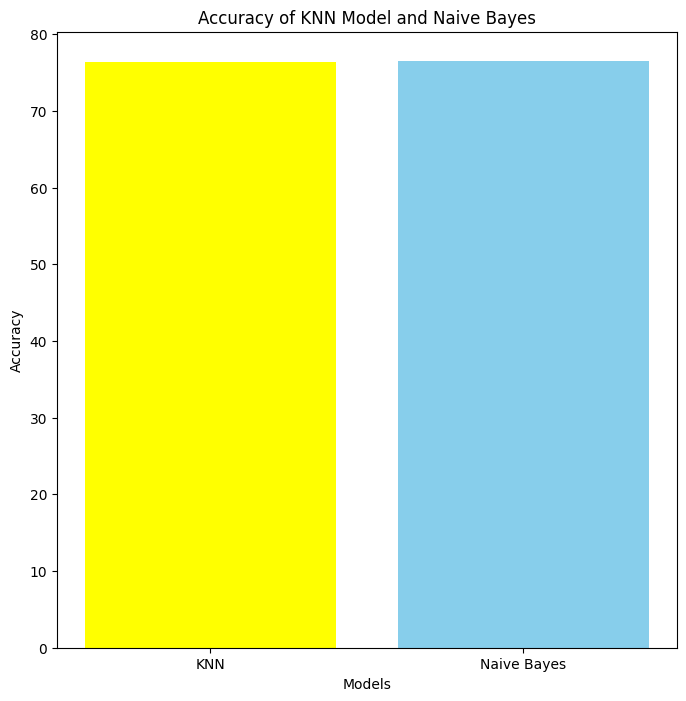

In [126]:
plt.figure(figsize = (8,8))
plt.bar(x,y, color = ['yellow', 'skyblue'])
plt.xlabel('Models')
plt.ylabel("Accuracy")
plt.title("Accuracy of KNN Model and Naive Bayes")
plt.show()


In [127]:
print ("Recall Score of Naive Bayes Model:", Recall_Score_of_Naive_Bayes)
print ("Recall Score of Naive Bayes Model:", Recall_Score_of_KNN)

Recall Score of Naive Bayes Model: 38.50139289045627
Recall Score of Naive Bayes Model: 33.33333333333333


In [128]:
x = ['KNN','Naive Bayes']
y = [Recall_Score_of_KNN, Recall_Score_of_Naive_Bayes]
y

[33.33333333333333, 38.50139289045627]

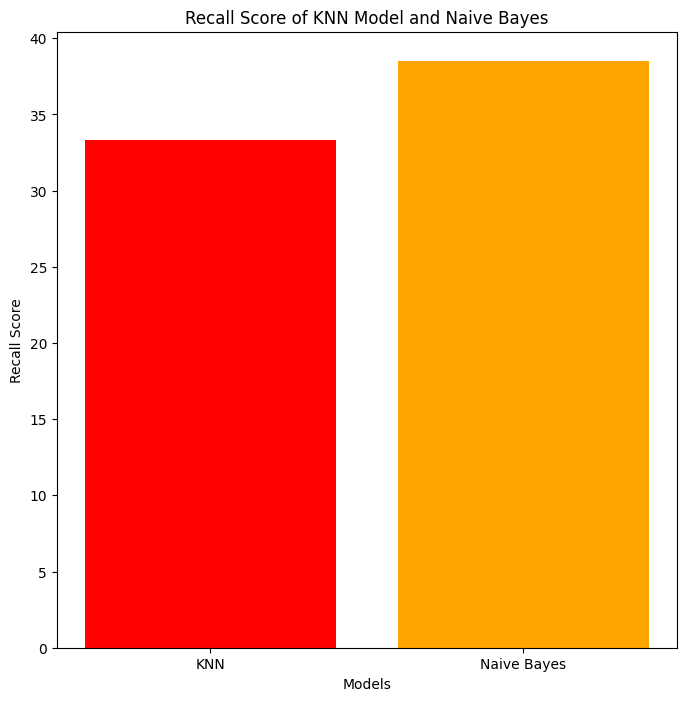

In [129]:
plt.figure(figsize = (8,8))
plt.bar(x,y, color = ['red', 'orange'])
plt.xlabel('Models')
plt.ylabel("Recall Score")
plt.title("Recall Score of KNN Model and Naive Bayes")
plt.show()

In [130]:
print ("Precision Score of Naive Bayes Model:", Precision_Score_of_Naive_Bayes)
print ("Precision Score of Naive Bayes Model:", Precision_Score_of_KNN)

Precision Score of Naive Bayes Model: 43.38346601563767
Precision Score of Naive Bayes Model: 25.457560496253535


In [131]:
x = ['KNN','Naive Bayes']
y = [Precision_Score_of_KNN, Precision_Score_of_Naive_Bayes]
y

[25.457560496253535, 43.38346601563767]

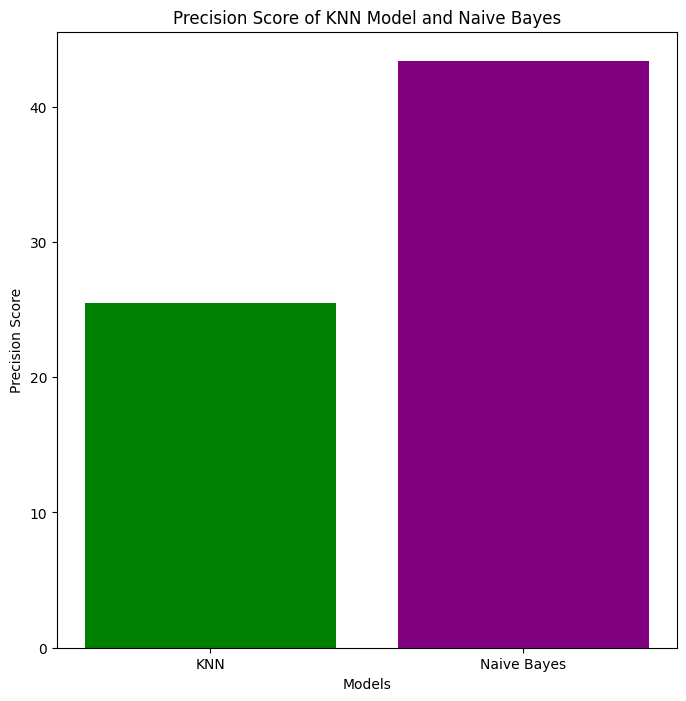

In [132]:
plt.figure(figsize = (8,8))
plt.bar(x,y, color = ['green', 'purple'])
plt.xlabel('Models')
plt.ylabel("Precision Score")
plt.title("Precision Score of KNN Model and Naive Bayes")
plt.show()

In [133]:
print ("F1 Score of Naive Bayes Model:", F1_Score_of_Naive_Bayes)
print ("F1 Score of Naive Bayes Model:", F1_Score_of_KNN)

F1 Score of Naive Bayes Model: 38.9026449868262
F1 Score of Naive Bayes Model: 28.867917958003968


In [134]:
x = ['KNN','Naive Bayes']
y = [F1_Score_of_KNN, F1_Score_of_Naive_Bayes]
y

[28.867917958003968, 38.9026449868262]

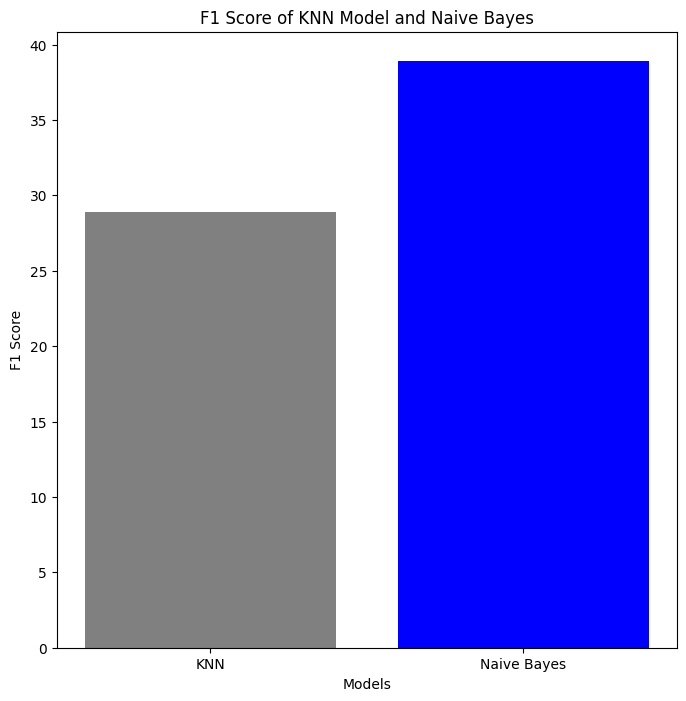

In [135]:
plt.figure(figsize = (8,8))
plt.bar(x,y, color = ['grey', 'blue'])
plt.xlabel('Models')
plt.ylabel("F1 Score")
plt.title("F1 Score of KNN Model and Naive Bayes")
plt.show()

## **Conclusion**

From applying a full ML pipeline to the Census Income dataset, the classification models are able to distinguish individuals earning above $50K vs those earning less, with reasonable performance as measured by accuracy, precision, recall, F1-score, and ROC-AUC. The results show that demographic and socio‐economic features (education, occupation, hours worked, etc.) carry predictive power for income levels.

However, as with all models, there are caveats:

* The dataset may have biases (sampling bias, societal bias) which can affect fairness
* Certain categorical encodings or feature engineering choices strongly influence performance
* Overfitting remains a risk, so it's important to validate on unseen data
* Model interpretability vs complexity trade‐off: simpler models are easier to explain; more complex models might yield slightly better accuracy
* Additional improvements could come from more advanced techniques, feature selection, or combining multiple models

Overall, this notebook demonstrates a clean and replicable approach to binary classification on real-world demographic data, and provides a foundation for further refinement and deployment.
